# Lab CNN — 01: Exploración del dataset

Exploración inicial del dataset de rostros humanos dividido en dos clases: **female** y **male**.

**Objetivos:**
- Contar imágenes por clase
- Explorar tamaños y tipos de archivo
- Generar un mosaico visual de ejemplos de ambas clases

## 0. Imports y configuración de rutas

In [ ]:
import random
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

%matplotlib inline

BASE_DIR = Path().resolve().parent    # scripts/ → sube a la raíz del proyecto
DATA_DIR = BASE_DIR / "data"
OUT_DIR  = BASE_DIR / "outputs"
OUT_DIR.mkdir(exist_ok=True)

CLASSES    = {"female": DATA_DIR / "female", "male": DATA_DIR / "male"}
EXTENSIONS = {".jpg", ".jpeg", ".png"}

print("Rutas configuradas:")
for cls, path in CLASSES.items():
    print(f"  {cls}: {path}  →  existe: {path.exists()}")

## 1. Conteo de imágenes por clase

In [2]:
def collect_images(folder: Path) -> list[Path]:
    return [p for p in folder.iterdir() if p.suffix.lower() in EXTENSIONS]

files = {cls: collect_images(path) for cls, path in CLASSES.items()}

total = sum(len(v) for v in files.values())
print(f"Total de imágenes: {total}")
for cls, paths in files.items():
    pct = len(paths) / total * 100
    print(f"  {cls:>8}: {len(paths):>5} imágenes  ({pct:.1f}%)")

Total de imágenes: 5418
    female:  2698 imágenes  (49.8%)
      male:  2720 imágenes  (50.2%)


## 2. Exploración de tamaños y tipos de archivo

Se toma una muestra aleatoria de 100 imágenes por clase para revisar dimensiones y extensiones.

In [3]:
def explore_sizes(paths: list[Path], sample: int = 100) -> dict:
    shapes, exts = [], []
    for p in random.sample(paths, min(sample, len(paths))):
        img = cv2.imread(str(p))
        if img is not None:
            shapes.append(img.shape[:2])  # (alto, ancho)
        exts.append(p.suffix.lower())
    return {"shapes": shapes, "exts": exts}

stats = {cls: explore_sizes(paths) for cls, paths in files.items()}

for cls, s in stats.items():
    ext_count = Counter(s["exts"])
    heights   = [h for h, w in s["shapes"]]
    widths    = [w for h, w in s["shapes"]]
    print(f"Clase '{cls}'")
    print(f"  Tipos de archivo : {dict(ext_count)}")
    print(f"  Alto  — min: {min(heights)}  max: {max(heights)}  promedio: {int(sum(heights)/len(heights))}")
    print(f"  Ancho — min: {min(widths)}  max: {max(widths)}  promedio: {int(sum(widths)/len(widths))}")
    print()

Clase 'female'
  Tipos de archivo : {'.jpg': 94, '.png': 6}
  Alto  — min: 320  max: 6000  promedio: 1242
  Ancho — min: 236  max: 4000  promedio: 953

Clase 'male'
  Tipos de archivo : {'.jpg': 99, '.jpeg': 1}
  Alto  — min: 259  max: 3749  promedio: 1002
  Ancho — min: 194  max: 2999  promedio: 751



### Distribución de tamaños (scatter plot)

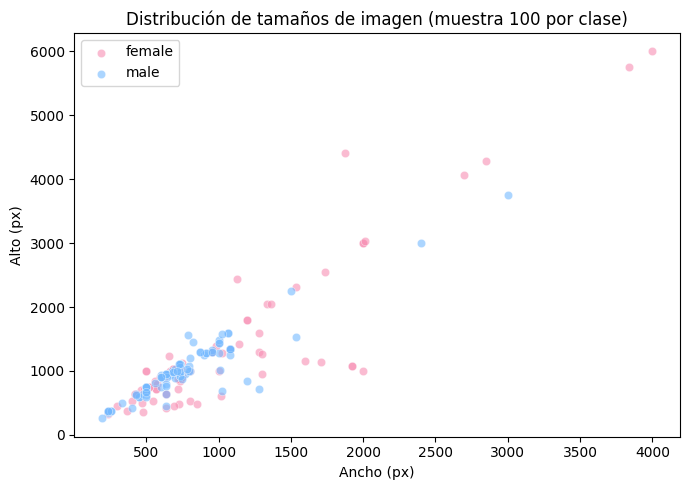

In [4]:
colors = {"female": "#f78fb3", "male": "#74b9ff"}

fig, ax = plt.subplots(figsize=(7, 5))
for cls, s in stats.items():
    widths  = [w for h, w in s["shapes"]]
    heights = [h for h, w in s["shapes"]]
    ax.scatter(widths, heights, alpha=0.6, label=cls, color=colors[cls], edgecolors="white", linewidths=0.4)

ax.set_xlabel("Ancho (px)")
ax.set_ylabel("Alto (px)")
ax.set_title("Distribución de tamaños de imagen (muestra 100 por clase)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Mosaico visual 4×4

Se muestran 8 imágenes de cada clase (columnas izquierdas = female, columnas derechas = male).

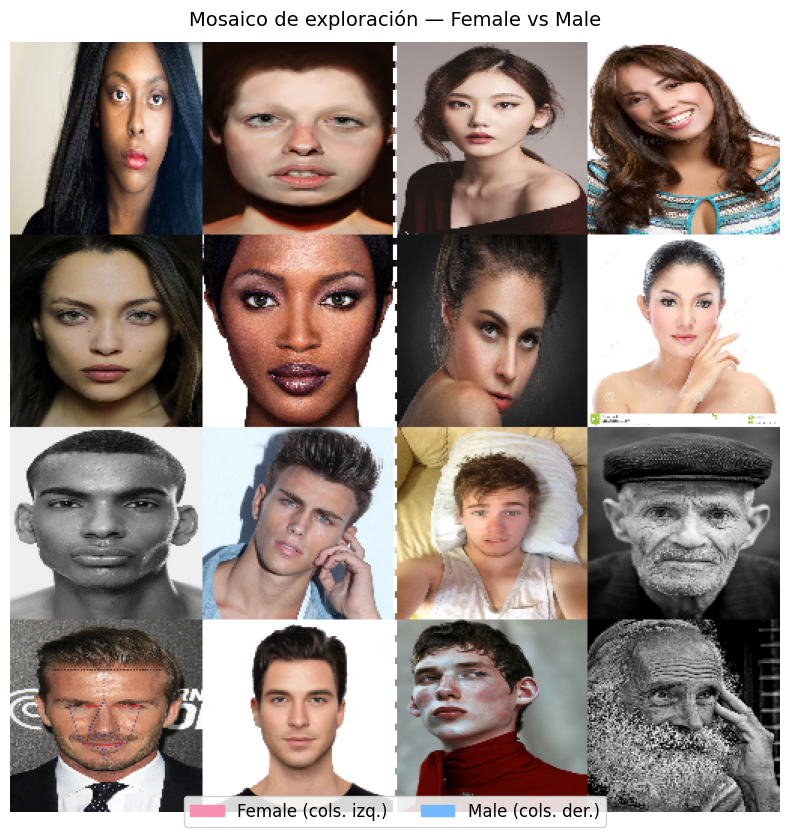

Mosaico guardado en: outputs/mosaico_exploracion.png


In [5]:
ROWS, COLS = 4, 4
HALF       = ROWS * COLS // 2   # 8 por clase
CELL_SIZE  = 128

def load_rgb(path: Path) -> np.ndarray:
    img = cv2.imread(str(path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, (CELL_SIZE, CELL_SIZE))

selected = {
    "female": random.sample(files["female"], HALF),
    "male":   random.sample(files["male"],   HALF),
}

cells = [load_rgb(p) for p in selected["female"]] + \
        [load_rgb(p) for p in selected["male"]]

mosaic = np.vstack([
    np.hstack(cells[r * COLS : (r + 1) * COLS])
    for r in range(ROWS)
])

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(mosaic)
ax.axis("off")
ax.axvline(x=2 * CELL_SIZE - 0.5, color="white", linewidth=3, linestyle="--")

patch_f = mpatches.Patch(color="#f78fb3", label="Female (cols. izq.)")
patch_m = mpatches.Patch(color="#74b9ff", label="Male (cols. der.)")
ax.legend(handles=[patch_f, patch_m], loc="lower center",
          bbox_to_anchor=(0.5, -0.03), ncol=2, fontsize=12, framealpha=0.85)
ax.set_title("Mosaico de exploración — Female vs Male", fontsize=14, pad=12)

out_path = OUT_DIR / "mosaico_exploracion.png"
fig.savefig(out_path, bbox_inches="tight", dpi=150)
plt.show()
print(f"Mosaico guardado en: {out_path.relative_to(BASE_DIR)}")

## 4. Resumen final

In [6]:
print("=" * 55)
print("  RESUMEN DE EXPLORACIÓN — LabCNN")
print("=" * 55)
print(f"\nTotal de imágenes : {total}")
print(f"Clases            : {list(files.keys())}")
print()
for cls, paths in files.items():
    s = stats[cls]
    ext_count = Counter(s["exts"])
    heights   = [h for h, w in s["shapes"]]
    widths    = [w for h, w in s["shapes"]]
    print(f"  [{cls}]  {len(paths)} imágenes")
    print(f"    Extensiones : {dict(ext_count)}")
    print(f"    Alto        : min={min(heights)} · max={max(heights)} · prom={int(sum(heights)/len(heights))} px")
    print(f"    Ancho       : min={min(widths)} · max={max(widths)} · prom={int(sum(widths)/len(widths))} px")
    print()
print(f"Mosaico guardado  : outputs/mosaico_exploracion.png")
print("=" * 55)

  RESUMEN DE EXPLORACIÓN — LabCNN

Total de imágenes : 5418
Clases            : ['female', 'male']

  [female]  2698 imágenes
    Extensiones : {'.jpg': 94, '.png': 6}
    Alto        : min=320 · max=6000 · prom=1242 px
    Ancho       : min=236 · max=4000 · prom=953 px

  [male]  2720 imágenes
    Extensiones : {'.jpg': 99, '.jpeg': 1}
    Alto        : min=259 · max=3749 · prom=1002 px
    Ancho       : min=194 · max=2999 · prom=751 px

Mosaico guardado  : outputs/mosaico_exploracion.png
